# HW2 - Classification

Here, I attempt to fit KNN and Logistic Regression to my dataset and analyze the models, especially by finding the error rate and AUC for both and also investigating how the MSE changes as a function of K.

Problem Statement:
The objective of this analysis is to build and test some clasification models on real-world data from the BTS which predict whether a flight will be delayed at arrival.
A flight is defined to be delayed if it arrives more than 15 minutes past its due arival time at the destination airport. This may be constructed as a binary response variable as:
Y=1 if the flight is delayed and 
Y=0 if the flight is not delayed.
The predictors used for this model are:
1. DEP_DELAY: departure delay in minutes,
2. AIR_TIME: flight time in minutes,
3. DISTANCE: flight distance.

The response variable is the binary arrival-delay indicator constructed from ARR_DELAY(Arrival Delay)

The original dataset contains 544,003 flight observations. After removing observations containing missing values in ARR_DELAY, DEP_DELAY, AIR_TIME, or DISTANCE, 517,222 observations remain for the analysis. 

Goal: The goal is to compare classification methods(I have used KNN and Logistic Regression) in their ability to predict whether an arriving flight will be delayed.

In [ ]:
# YOUR CODE HERE - you can create as many additional Markdown or Code cells as needed
# Suman's code
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.neighbors import KNeighborsClassifier
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    accuracy_score,
    mean_squared_error,
    roc_auc_score,
    roc_curve
)
df=pd.read_csv("T_ONTIME_REPORTING.csv")

# Using the same dataset from HW1
data=df[["ARR_DELAY", "DEP_DELAY", "AIR_TIME", "DISTANCE"]].dropna() # so that empty values are rejected


<Figure size 600x600 with 0 Axes>

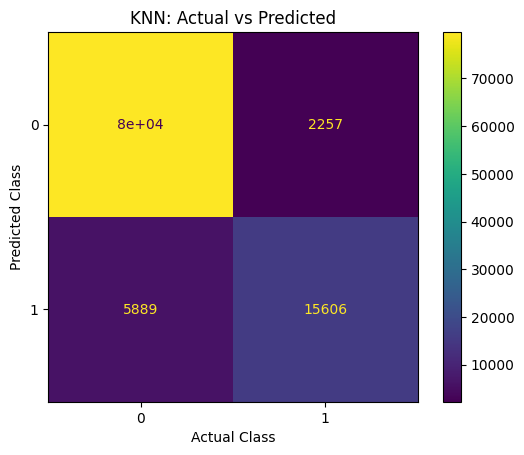

In [17]:
model=KNeighborsClassifier(n_neighbors=5)
scaler=StandardScaler()
y = (data["ARR_DELAY"] >= 15).astype(int)
X=data[["DEP_DELAY", "AIR_TIME", "DISTANCE"]]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
) # We split the data into training and test datasets
# Let's scale the data as the magnitudes are very different
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test) 
model.fit(X_train,y_train)
y_predicted=model.predict(X_test)
plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_predicted
) # A confusion matrix is useful as a plot would simply have overlaps at 4 points
plt.xlabel("Actual Class")
plt.ylabel("Predicted Class")
plt.title("KNN: Actual vs Predicted")
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.show()

Let's check the errors on the test dataset

In [6]:
y_prob = model.predict_proba(X_test)[:, 1]
knn_accuracy = accuracy_score(y_test, y_predicted)
knn_error = 1 - knn_accuracy
knn_auc = roc_auc_score(y_test, y_prob)
print("KNN Test Error Rate:", knn_error)
print("KNN AUC:", knn_auc)

KNN Test Error Rate: 0.07874716032674367
KNN AUC: 0.8988358301184165


Let's now fit Logistic Regression!

In [16]:
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
y_pred_log = lr.predict(X_test)
y_prob_log = lr.predict_proba(X_test)[:, 1]
log_error = 1 - accuracy_score(y_test, y_pred_log)
log_auc = roc_auc_score(y_test, y_prob_log)
print("Logistic Regression Test Error Rate:", log_error)
print("Logistic Regression AUC:", log_auc)

Logistic Regression Test Error Rate: 0.07392334090579533
Logistic Regression AUC: 0.9312520981581056


Analysis of KNN and Logistic Regression results:
1. Based on Test Error rate: The KNN produced a Test Error rate of 0.07875 which means that approximately 7.87% of test observations were classified incorrectly, and consequently, the classifier achieved an accuracy of 92.13%. The Logistic Regression classifier produced a Test Error rate og 0.0739 which means approximately 7.39% of the data was classified incorrectly and the classifier had an accuracy of 92.61%. Logistic Regression performed slightly better than KNN for this dataset. The difference is error is quite small(0.00485), indicating that both models have comparatively equal performance with overall high accuracy.
2. Based on AUC: The KNN classifier produced an AUC of 0.89884 while Logistic Regression produced an AUC of 0.93125. An AUC of 0.5 implies random classification while an AUC of 1 implies ideal classification. As Logistic Regression has a higher AUC, it shows a better ability to classify between the two classes for all observations in this datset. 

Now let's compare KNN models for different values of k(Specifically 0<=k<=15)

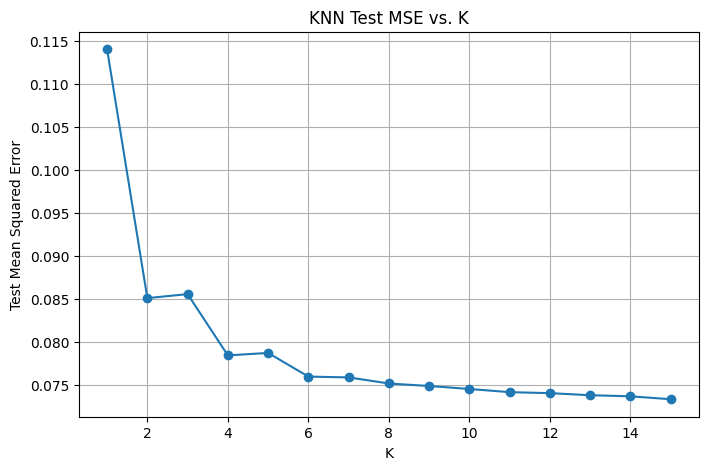

In [18]:
k_values = range(1, 16)
test_mse = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    test_mse.append(mse)
plt.figure(figsize=(8, 5))
plt.plot(k_values, test_mse, marker="o")
plt.xlabel("K")
plt.ylabel("Test Mean Squared Error")
plt.title("KNN Test MSE vs. K")
plt.grid()
plt.show()

Analysis of results:
The MSE decreases with an increasing value of K. Smaller K leads to overfitting of the curve(because local effects are much more prominent)and much higher variance while a higher K represents a loss of features(higher bias). The maximum value of MSE is approximately 0.114 at K=1, and then it drops sharply and smoothens out as K is increased further and achieves its minimum at K=15. An ideal value of K would be 7-9, ensuring that the model neither has too much bias or variance.